# Análisis de clientes de ConnectaTel

## Contexto del proyecto

ConnectaTel es una empresa de telecomunicaciones con operaciones en Latinoamérica. Este proyecto analiza la información disponible hasta 2024 para conocer la composición de su base de clientes, sus patrones de uso y las diferencias observadas entre los planes Básico y Premium.

## Objetivo

Construir un perfil estadístico de los clientes, evaluar la calidad de los datos, identificar comportamientos atípicos, crear segmentos de edad y uso, y traducir los resultados en recomendaciones de negocio respaldadas por evidencia.

## Fuentes de datos

- `plans.csv`: características, beneficios y precios de los planes.
- `users_latam.csv`: información demográfica, plan contratado, fecha de registro y cancelación de los clientes.
- `usage.csv`: registros de llamadas y mensajes realizados durante 2024.

## Alcance del análisis

El notebook documenta la carga y validación de los datos, su limpieza, la construcción del perfil de uso por cliente, el análisis de distribuciones y valores atípicos, la segmentación de usuarios y la elaboración de conclusiones ejecutivas.

## Estructura

1. Carga y exploración de datos.
2. Evaluación de calidad.
3. Limpieza y tratamiento de inconsistencias.
4. Construcción del perfil de uso.
5. Análisis de distribuciones y valores atípicos.
6. Segmentación de clientes.
7. Análisis ejecutivo para stakeholders.

Antes de las conclusiones se incluye un bloque complementario con validaciones y cruces adicionales. Este bloque amplía el análisis, pero no sustituye las actividades obligatorias del proyecto.



---
## 1. Carga y exploración de datos

### 1.1 Carga y revisión inicial

En esta sección se importan las librerías necesarias y se cargan los archivos `plans.csv`, `users_latam.csv` y `usage.csv` en los DataFrames `plans`, `users` y `usage`.

La revisión inicial incluye las primeras filas, dimensiones, columnas y tipos de datos de cada fuente. Su propósito es confirmar que los archivos se cargaron correctamente y reconocer su estructura antes de iniciar la limpieza.



In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('plans.csv')
users = pd.read_csv('users_latam.csv')
usage = pd.read_csv('usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
print(plans.head())

  plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  


In [4]:
# mostrar las primeras 5 filas de users
print(users.head())

   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  


In [5]:
# mostrar las primeras 5 filas de usage
print(usage.head())

   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN


In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 2. Evaluación de calidad de los datos

### 2.1 Revisión de valores nulos

Se cuantifican los valores ausentes y su proporción en cada columna de `users` y `usage`. El dataset `plans` no requiere una revisión adicional de nulos porque contiene dos registros completos.

Esta evaluación permite distinguir entre ausencias que representan un problema de calidad, valores que no aplican por el tipo de actividad y campos que deben conservarse sin imputación para evitar introducir información artificial.

In [10]:
# cantidad de nulos para users
print("Cantidad de valores nulos para users")
print(users.isna().sum())
print()
print("Proporción de valores nulos para users")
print(users.isna().mean())

Cantidad de valores nulos para users
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos para users
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print("Cantidad de valores nulos para usage")
print(usage.isna().sum())
print()
print("Proporción de valores nulos para usage")
print(usage.isna().mean())

Cantidad de valores nulos para usage
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos para usage
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


### Diagnóstico de valores nulos

- **`users.city`:** se registraron 469 valores nulos, equivalentes al 11.73% de la base. Se conservaron como datos ausentes porque no existe información suficiente para recuperar la ciudad sin introducir una categoría artificial. Los registros con `"?"` se revisan posteriormente como valores inválidos.

- **`users.churn_date`:** se registraron 3,534 valores nulos, equivalentes al 88.35% de los clientes. Estos casos se conservan porque representan usuarios sin una cancelación registrada y no un error de captura.

- **`usage.date`:** se registraron 50 valores nulos, equivalentes al 0.125% de las actividades. Estos registros no deben utilizarse en comparaciones temporales cuando la fecha no pueda recuperarse.

- **`usage.duration`:** se registraron 22,076 valores nulos, equivalentes al 55.19% de las actividades. Su relación con el tipo de servicio se valida antes de determinar su tratamiento.

- **`usage.length`:** se registraron 17,896 valores nulos, equivalentes al 44.74% de las actividades. Su relación con el tipo de servicio se valida antes de determinar su tratamiento.

El valor `"?"` identificado en `city` no aparece en el conteo inicial de nulos porque está almacenado como texto. Por esta razón, se analiza como un valor inválido en la siguiente sección.

### 2.2 Detección de valores inválidos y sentinels

Las variables numéricas se revisan mediante estadísticas descriptivas y las variables categóricas mediante sus valores únicos y frecuencias.

El objetivo es identificar valores incompatibles con el significado de cada variable, documentar su magnitud y definir un tratamiento que conserve la mayor cantidad posible de información válida.

In [12]:
# explorar columnas numéricas de users
columnas_numericas = ['user_id', 'age']

print('Resumen estadístico de users.user_id & age')
print(users[columnas_numericas].describe())
print()
print('Registros con age = -999:', users['age'].eq(-999).sum() )

Resumen estadístico de users.user_id & age
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000

Registros con age = -999: 55


- La columna `user_id` contiene identificadores entre 10000 y 13999. No se observan valores inválidos o sentinels.
  

- La columna `age` presenta el valor mínimo `-999`, el cual es inválido y funciona como sentinel.




In [13]:
# explorar columnas numéricas de usage
columnas_numericas_usage = ['user_id', 'id']

print('Resumen estadístico de usage.user_id & id')
print(usage[columnas_numericas_usage].describe())

Resumen estadístico de usage.user_id & id
            user_id           id
count  40000.000000  40000.00000
mean   12002.405975  20000.50000
std     1157.279564  11547.14972
min    10000.000000      1.00000
25%    10996.000000  10000.75000
50%    12013.000000  20000.50000
75%    13005.000000  30000.25000
max    13999.000000  40000.00000


- Las columnas `id` y `user_id` contienen identificadores dentro de los rangos esperados: `id` va de 1 a 40000 y `user_id` de 10000 a 13999. No se observan valores inválidos o sentinels.


In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print('Resumen categórico de users.city & plan')
print(users[columnas_user].describe())
print()
print(
    'Registros con city = "?":',
    users['city'].eq('?').sum()
)

Resumen categórico de users.city & plan
          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595

Registros con city = "?": 96


- La columna `city` contiene 7 valores únicos y Bogotá es la categoría más frecuente, con 808 registros. También se identificó `"?"`, qué representan 96 valores inválidos o sentinel.

- La columna `plan` contiene 2 valores únicos y `Basico` es el más frecuente, con 2595 registros. No se observan valores inválidos o sentinels.


In [15]:
# explorar columna categórica de usage
print('Resumen categórico de usage.type')
usage['type'].describe()

Resumen categórico de usage.type


,type
count,40000
unique,2
top,text
freq,22092


- La columna `type` contiene 2 valores únicos y `text` es el más frecuente, con 22092 registros. No se observan valores inválidos o sentinels.


### Diagnóstico de valores inválidos y sentinels

Se identificaron 55 registros con `age = -999` y 96 registros con `city = "?"`.

El sentinel de `age` representa el 1.38% de los clientes y se sustituye por la mediana de las edades válidas. El valor `"?"` representa el 2.40% de la base y se convierte en un valor nulo porque no existe información suficiente para asignar una ciudad.

No se identificaron sentinels adicionales en las demás columnas revisadas.

### 2.3 Revisión y estandarización de fechas

Las columnas de fecha se convierten con control de errores y se revisan por año para identificar registros fuera del periodo de observación, establecido hasta 2024.

Esta validación permite separar las fechas válidas de aquellas que no pueden utilizarse para calcular antigüedad, realizar comparaciones temporales o estudiar el momento de una cancelación.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts())

reg_date
2024    1330
2023    1316
2022    1314
2026      40
Name: count, dtype: int64


En `reg_date`, se registraron 1,314 usuarios en 2022, 1,316 en 2023 y 1,330 en 2024. También aparecen 40 registros del año 2026, los cuales están fuera del periodo establecido (2024) .

In [19]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts())

date
2024.0    39950
Name: count, dtype: int64


En `date`, los 39,950 registros con fecha válida pertenecen al año 2024. No se observan años fuera de rango, por lo que el análisis temporal se basará en estas fechas.   



### Diagnóstico de fechas fuera de rango

En `users.reg_date` se identificaron 40 fechas correspondientes a 2026, equivalentes al 1.00% de los clientes. Debido a que el periodo de observación termina en 2024, estas fechas se consideran inválidas.

Los clientes se conservan y únicamente se invalida la fecha inconsistente. Eliminar las filas también descartaría información válida sobre edad, ciudad y plan. En `usage.date` no se encontraron años fuera del periodo esperado, aunque permanecen 50 actividades sin fecha.

-----
## 3. Limpieza y tratamiento de inconsistencias

### 3.1 Corrección de sentinels y fechas imposibles

La limpieza conserva los registros válidos y modifica únicamente los campos cuya inconsistencia fue comprobada:

- `age = -999` se sustituye por la mediana de las edades válidas.
- `city = "?"` se convierte en un valor nulo con `pd.NA`.
- Las fechas posteriores a 2024 se convierten en valores de fecha nulos.

Después de aplicar estas reglas se verifican nuevamente las variables afectadas para confirmar el resultado del tratamiento.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana =  users.loc[users['age'] != -999, 'age'].median()

users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
print("Resumen estadístico de age después de la limpieza:")
users['age'].describe()

Resumen estadístico de age después de la limpieza:


,age
count,4000.000000
mean,48.136000
std,17.689919
min,18.000000
25%,33.000000
50%,48.000000
75%,63.000000
max,79.000000


In [21]:
# Reemplazar ? por NA en city

users['city'] = users['city'].replace('?', pd.NA)


# Verificar cambios
print("Sentinels '?' restantes en city:",users['city'].isin(['?']).sum())
print("Valores nulos en city:",users['city'].isna().sum())


Sentinels '?' restantes en city: 0
Valores nulos en city: 565


In [22]:
# Marcar fechas futuras como NA para reg_date

users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios

print("Registros por año después de la limpieza:")
print(users['reg_date'].dt.year.value_counts())
print("Fechas nulas en reg_date:", users['reg_date'].isna().sum())

Registros por año después de la limpieza:
reg_date
2024.0    1330
2023.0    1316
2022.0    1314
Name: count, dtype: int64
Fechas nulas en reg_date: 40


### 3.2 Tratamiento de valores nulos en los registros de uso

Los valores ausentes de `duration` y `length` se analizan según la columna `type` para determinar si responden a la estructura del registro.

`duration` corresponde a llamadas y `length` a mensajes. Si la ausencia depende del tipo de actividad, los valores se conservan como nulos porque completarlos asignaría características que no corresponden al servicio registrado.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration

missing_duration_by_type = (
    usage['duration']
    .isna()
    .groupby(usage['type'])
    .mean()
)

print(missing_duration_by_type)

type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [24]:
# Verificación MAR en usage (Missing At Random) para length
missing_length_by_type = (
    usage['length']
    .isna()
    .groupby(usage['type'])
    .mean()
)

print(missing_length_by_type)

type
call    0.99933
text    0.00000
Name: length, dtype: float64


### Diagnóstico de valores nulos en `duration` y `length`

La ausencia de información depende de la variable observable `type`. En `duration`, los mensajes presentan 99.93% de valores nulos y las llamadas 0%; en `length`, las llamadas presentan 99.93% de valores nulos y los mensajes 0%.

Este patrón confirma que los campos cumplen funciones diferentes según el tipo de actividad. Por esta razón, los valores se conservan como nulos: imputarlos generaría registros con características que no corresponden a llamadas o mensajes.

---

## 4. Construcción del perfil de uso por cliente

### 4.1 Agregación del comportamiento de uso

Los registros de `usage` se agrupan por `user_id` para construir tres métricas históricas por cliente:

- `cant_mensajes`: cantidad total de mensajes.
- `cant_llamadas`: cantidad total de llamadas.
- `cant_minutos_llamada`: minutos acumulados en llamadas.

Las métricas se integran con `users` para crear `user_profile`, la tabla principal utilizada en las etapas posteriores del análisis.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (
    usage.groupby('user_id')
    .agg({
        'is_text': 'sum',
        'is_call': 'sum',
        'duration': 'sum'
    })
    .reset_index()
)

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on='user_id',
    how='left'
)

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 Resumen estadístico por usuario durante 2024

Se calculan estadísticas descriptivas de las variables numéricas para conocer su tendencia central, dispersión, rango y posibles valores extremos. También se revisa la distribución porcentual de los clientes entre los planes Básico y Premium.

Esta revisión establece una referencia cuantitativa antes de analizar las distribuciones y construir los segmentos de clientes.

In [28]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]
print("Resumen estadístico por usuario durante el 2024")
print()
user_profile[columnas_numericas].describe()

Resumen estadístico por usuario durante el 2024



,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
distribucion_plan = (
    user_profile['plan']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
print("Distribución porcentual del tipo de plan")
print(distribucion_plan)


Distribución porcentual del tipo de plan
plan
Basico     64.88
Premium    35.12
Name: proportion, dtype: float64


-----

## 5. Análisis de distribuciones y valores atípicos

### 5.1 Distribución de clientes y uso

Se analizan las distribuciones de `age`, `cant_mensajes`, `cant_llamadas` y `cant_minutos_llamada` mediante histogramas diferenciados por plan.

Las visualizaciones permiten identificar la forma de cada distribución, su concentración y posibles diferencias entre Básico y Premium. La altura de las barras se interpreta considerando que ambos planes tienen tamaños de muestra diferentes.

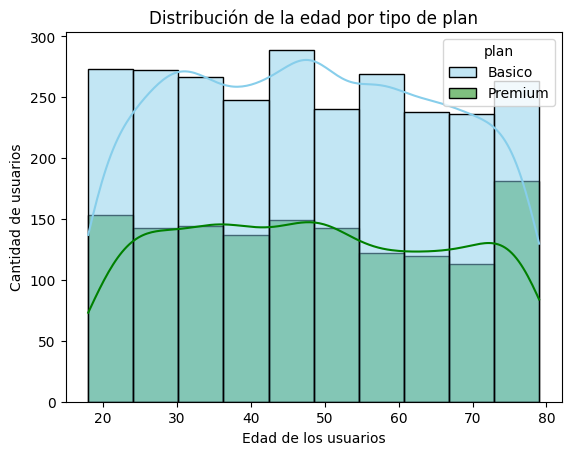

In [30]:
# Histograma para visualizar la edad (age)

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    bins=10,
    kde=True,
    palette=['skyblue', 'green'],
    edgecolor='black'
)

plt.xlabel('Edad de los usuarios')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de la edad por tipo de plan')

plt.show()

💡Insights:

En el conjunto total, la edad presenta una distribución aproximadamente uniforme, con una media de 48.14 años y una mediana de 48. El histograma no muestra una separación visual clara entre Básico y Premium. Sin embargo, debido a la diferencia en el tamaño de ambos planes y a que no se calcularon estadísticas separadas por plan, no puede concluirse que sus distribuciones sean equivalentes.

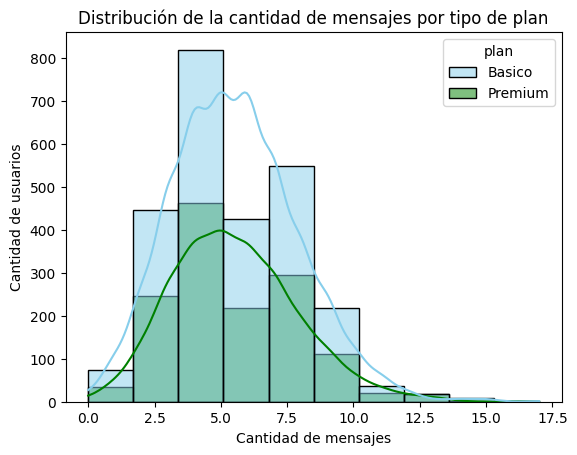

In [31]:
# Histograma para visualizar la cant_mensajes

sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    bins=10,
    kde=True,
    palette=['skyblue', 'green'],
    edgecolor='black'
)

plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de la cantidad de mensajes por tipo de plan')

plt.show()

💡Insights:

En el conjunto total, el 50% central de los usuarios envía entre 4 y 7 mensajes. La distribución presenta sesgo hacia la derecha y alcanza un máximo de 17 mensajes. No se aprecia una separación visual clara entre Básico y Premium, pero el gráfico no permite afirmar que ambos planes tengan exactamente el mismo comportamiento.

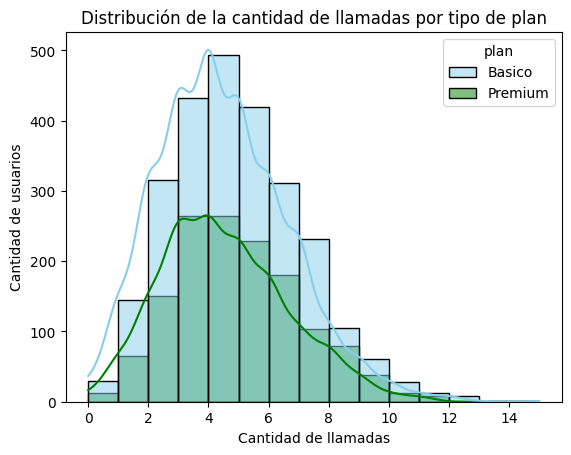

In [32]:
# Histograma para visualizar la cant_llamadas

sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    bins=15,
    kde=True,
    palette=['skyblue', 'green'],
    edgecolor='black'
)

plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de la cantidad de llamadas por tipo de plan')

plt.show()


💡Insights:

En el conjunto total, el 50% central de los usuarios realiza entre 3 y 6 llamadas. La distribución presenta sesgo hacia la derecha y alcanza un máximo de 15 llamadas. No se aprecia una separación visual clara entre Básico y Premium, aunque se necesitarían estadísticas por plan para confirmar esa similitud.

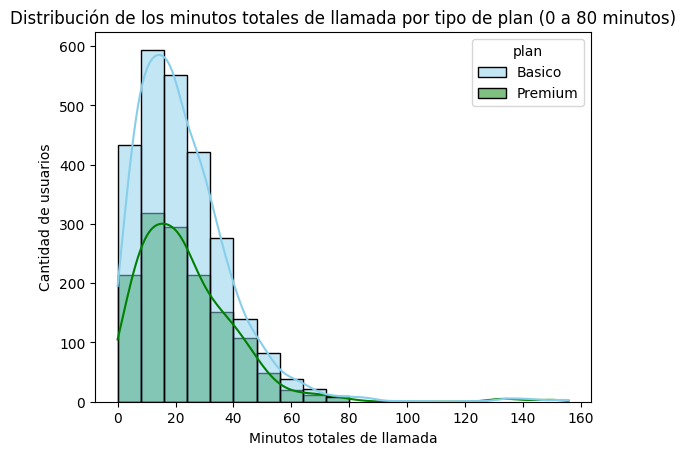

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    bins=10,
    binrange=(0, 80),
    kde= True,
    palette=['skyblue', 'green'],
    edgecolor='black'
)

plt.xlabel('Minutos totales de llamada')
plt.ylabel('Cantidad de usuarios')
plt.title(
    'Distribución de los minutos totales de llamada por tipo de plan '
    '(0 a 80 minutos)'
)

plt.show()

💡Insights:

Se utilizó un rango de 0 a 80 minutos porque los valores extremos extendían demasiado el eje horizontal. La mayor parte de los usuarios se concentra entre 0 y 40 minutos y la distribución presenta sesgo hacia la derecha. La comparación visual no muestra una separación clara entre los planes, pero no permite afirmar que sus distribuciones sean equivalentes.

**Nota general**: Las barras de Básico son más altas porque existen 2595 usuarios Básico frente a 1405 Premium. Esto no demuestra una mayor proporción de uso dentro de ese plan.

### 5.2 Identificación y tratamiento de valores atípicos

Los valores extremos de `age`, `cant_mensajes`, `cant_llamadas` y `cant_minutos_llamada` se identifican mediante boxplots y el método del rango intercuartílico (IQR).

La clasificación estadística no implica automáticamente un error de captura. La decisión de conservar o retirar un valor depende de su viabilidad dentro del comportamiento de uso y de la evidencia disponible.

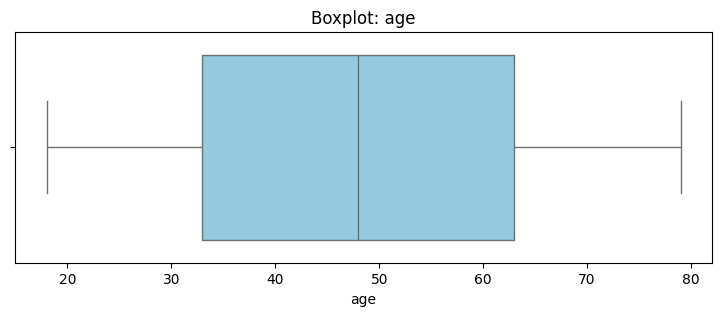

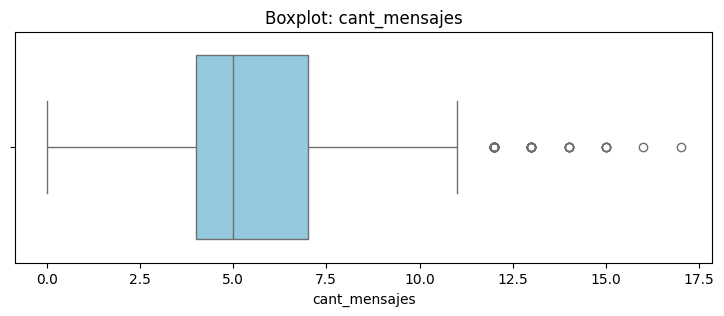

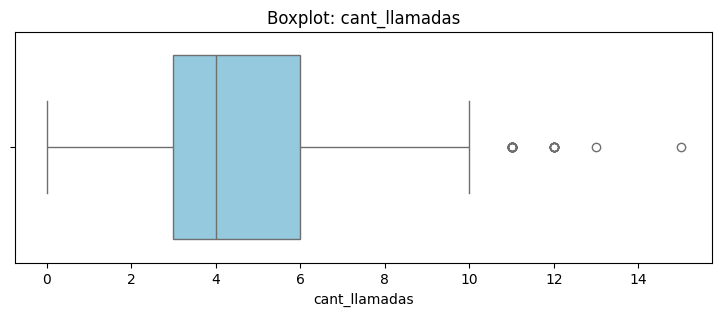

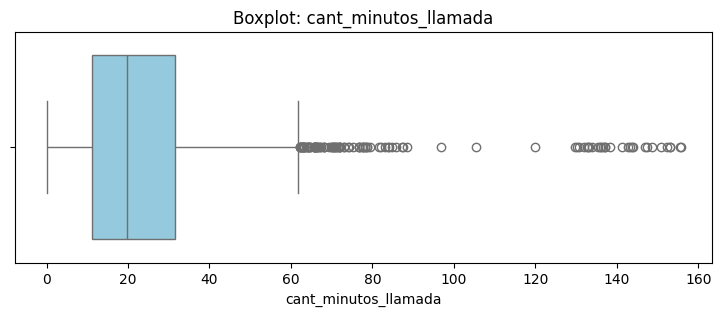

In [34]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(9, 3))

    sns.boxplot(
        data=user_profile,
        x=col,
        color='skyblue'
    )

    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights:
- Age: **No presenta valores fuera de los bigotes del boxplot**; por lo tanto, no se identifican valores atípicos mediante el método IQR.
- cant_mensajes: **Presenta valores atípicos en el extremo superior**, aproximadamente entre 12 y 17 mensajes. No se observan valores atípicos inferiores.
- cant_llamadas: **Presenta valores atípicos superiores**, aproximadamente entre 11 y 15 llamadas. No se observan valores atípicos inferiores.
- cant_minutos_llamada: **Presenta numerosos valores atípicos superiores**, algunos cercanos a 156 minutos. Es la variable con los valores extremos más alejados del bigote superior.

**Nota**: Los boxplots identifican valores estadísticamente atípicos, pero no permiten concluir que sean errores.

In [35]:
# Calcular límites con el método IQR
columnas_limites =  [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

limites_superiores = {}

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR
    limites_superiores[col] = limite_superior

    print(f'{col}:')
    print(f'Q1: {Q1}')
    print(f'Q3: {Q3}')
    print(f'IQR: {IQR}')
    print(f'Límite superior: {limite_superior}')
    print()



cant_mensajes:
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite superior: 11.5

cant_llamadas:
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite superior: 10.5

cant_minutos_llamada:
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite superior: 61.8575



In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


### Decisión sobre los valores atípicos

- **Cantidad de mensajes:** se mantienen los valores atípicos. El límite superior calculado mediante IQR es 11.5 y el valor máximo es 17. Los registros entre 12 y 17 mensajes son poco frecuentes, pero posibles, y no existe evidencia de que correspondan a errores de captura.

- **Cantidad de llamadas:** se mantienen los valores atípicos. El límite superior es 10.5 y el máximo es 15 llamadas. Los registros entre 11 y 15 llamadas pueden representar clientes con un nivel elevado de uso.

- **Minutos de llamada:** se mantienen los valores atípicos y se considera su influencia en las medidas agregadas. El límite superior es 61.8575 minutos y el máximo alcanza 155.69 minutos. Estos valores pueden corresponder a llamadas prolongadas y no deben eliminarse sin evidencia de error.

En conjunto, los valores extremos se conservan porque representan comportamientos posibles. Su interpretación se realiza por separado para evitar que distorsionen las conclusiones sobre el comportamiento habitual de la base.

---

## 6. Segmentación de clientes

### 6.1 Segmentación por nivel de uso

Los clientes se clasifican mediante reglas basadas en `cant_llamadas` y `cant_mensajes`:

- **Bajo uso:** menos de 5 llamadas y menos de 5 mensajes.
- **Uso medio:** menos de 10 llamadas y menos de 10 mensajes, después de aplicar la regla de bajo uso.
- **Alto uso:** clientes que no cumplen las condiciones anteriores.

La clasificación se almacena en la columna `grupo_uso` de `user_profile` y permite comparar la concentración de usuarios entre distintos niveles de actividad.

In [37]:
# Crear columna grupo_uso
columnas_uso = ['cant_llamadas', 'cant_mensajes']
user_profile[columnas_uso] = user_profile[columnas_uso].fillna(0)

# Función para clasificar a cada usuario
def clasificar_uso(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']

    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

# Aplicar la función fila por fila
user_profile['grupo_uso'] = user_profile.apply(
    clasificar_uso,
    axis=1
)

In [38]:
# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


In [39]:
# Verificar la cantidad de usuarios por grupo
user_profile['grupo_uso'].value_counts(dropna=False)

,count
grupo_uso,
Uso medio,2943
Bajo uso,779
Alto uso,278


### 6.2 Segmentación por edad

Los clientes se clasifican en tres grupos mediante la variable `age`:

- **Joven:** menor de 30 años.
- **Adulto:** desde 30 y menor de 60 años.
- **Adulto Mayor:** 60 años o más.

La clasificación se almacena en `grupo_edad` y permite analizar la composición de la base desde una perspectiva demográfica.

In [40]:
# Crear columna grupo_edad

def clasificar_edad(row):
    edad = row['age']

    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

# Aplicar la función fila por fila
user_profile['grupo_edad'] = user_profile.apply(
    clasificar_edad,
    axis=1
)


In [41]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


In [42]:
# Verificar la cantidad de usuarios por edad

user_profile['grupo_edad'].value_counts(dropna=False)

,count
grupo_edad,
Adulto,2018
Adulto Mayor,1222
Joven,760


### 6.3 Distribución de los segmentos

La composición de `grupo_uso` y `grupo_edad` se presenta mediante gráficos de frecuencia. Estas visualizaciones permiten identificar los grupos con mayor presencia y sirven como base para los cruces posteriores entre edad, uso y plan.

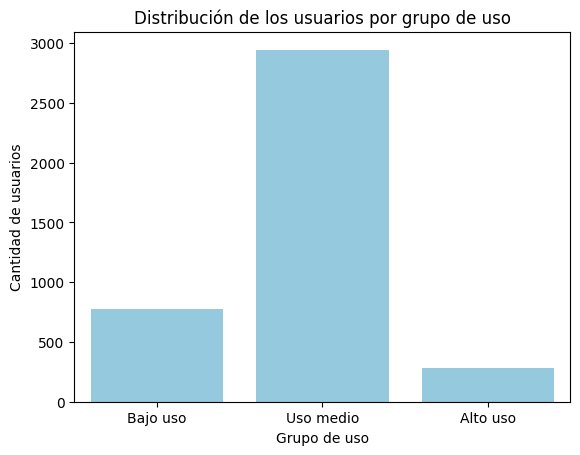

In [43]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso', 'Uso medio', 'Alto uso'],
    color='skyblue'
)

plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de los usuarios por grupo de uso')

plt.show()

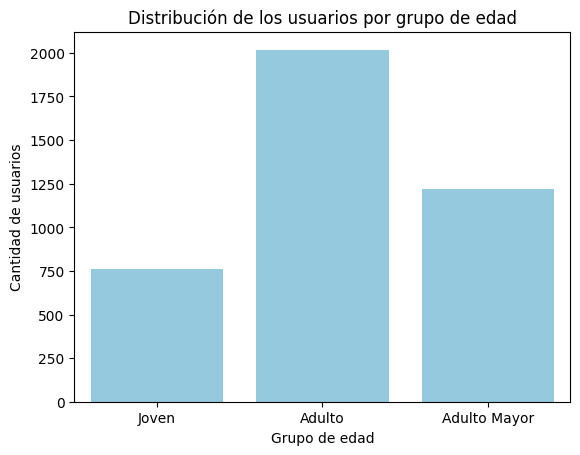

In [44]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=['Joven', 'Adulto', 'Adulto Mayor'],
    color='skyblue'
)

plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de los usuarios por grupo de edad')

plt.show()

---

## Análisis complementario para fortalecer el insight ejecutivo

Este bloque amplía el análisis obligatorio mediante validaciones y cruces adicionales. Incluye controles de calidad por tipo de actividad, la combinación entre edad, nivel de uso y plan, la cuantificación de valores atípicos y un análisis descriptivo de las cancelaciones registradas.

Los resultados se utilizan como evidencia complementaria para las conclusiones ejecutivas. No sustituyen las actividades solicitadas en las secciones anteriores ni deben interpretarse como relaciones causales.

In [45]:
#Validaciones complementarias de calidad

# Crear una copia independiente para el análisis complementario
analisis_complementario = user_profile.copy()


# ============================================================
# 1. VALIDAR CAMPOS SEGÚN EL TIPO DE ACTIVIDAD
# ============================================================

mensajes_con_duracion = (
    usage['type'].eq('text')
    & usage['duration'].notna()
).sum()

llamadas_con_longitud = (
    usage['type'].eq('call')
    & usage['length'].notna()
).sum()

print('Validación de campos según el tipo de actividad')
print('Mensajes con duración informada:', mensajes_con_duracion)
print('Llamadas con longitud informada:', llamadas_con_longitud)


# ============================================================
# 2. RECALCULAR LOS MINUTOS UTILIZANDO SOLO LLAMADAS
# ============================================================

# Guardar la métrica original únicamente para compararla
minutos_originales = (
    analisis_complementario['cant_minutos_llamada'].copy()
)

# Usuarios que sí tienen algún registro en usage
usuarios_con_uso = pd.Index(
    usage['user_id'].dropna().unique(),
    name='user_id'
)

# Sumar duration únicamente cuando el registro corresponde a llamada
minutos_llamada_por_usuario = (
    usage.loc[usage['type'].eq('call')]
    .groupby('user_id')['duration']
    .sum(min_count=1)
    .reindex(usuarios_con_uso, fill_value=0)
)

# Incorporar la métrica validada solo en la copia complementaria
analisis_complementario['cant_minutos_llamada'] = (
    analisis_complementario['user_id']
    .map(minutos_llamada_por_usuario)
)

usuarios_con_ajuste_minutos = (
    minutos_originales
    .fillna(-1)
    .round(10)
    .ne(
        analisis_complementario['cant_minutos_llamada']
        .fillna(-1)
        .round(10)
    )
    .sum()
)

print(
    'Usuarios cuyo total de minutos cambia al excluir '
    'duraciones registradas en mensajes:',
    usuarios_con_ajuste_minutos
)


# ============================================================
# 3. RECUPERAR Y VALIDAR CHURN_DATE
# ============================================================

# Leer churn_date como texto para conservar su formato original
churn_original = pd.read_csv(
    'users_latam.csv',
    usecols=['user_id', 'churn_date'],
    dtype={'churn_date': 'string'}
)

# Convertir la notación científica con coma decimal
churn_numerico = pd.to_numeric(
    churn_original['churn_date']
    .str.strip()
    .str.replace(',', '.', regex=False),
    errors='coerce'
)

# Convertir el timestamp Unix expresado en nanosegundos
churn_original['churn_date_convertida'] = pd.to_datetime(
    churn_numerico,
    unit='ns',
    errors='coerce'
)

# Relacionar la fecha recuperada con cada usuario
mapa_churn = (
    churn_original
    .set_index('user_id')['churn_date_convertida']
)

analisis_complementario['churn_date'] = (
    analisis_complementario['user_id']
    .map(mapa_churn)
)

# Registrar la existencia original de una cancelación
analisis_complementario['con_cancelacion_registrada'] = (
    analisis_complementario['churn_date'].notna()
)

# Identificar fechas de cancelación anteriores al registro
analisis_complementario['churn_date_inconsistente'] = (
    analisis_complementario['reg_date'].notna()
    & analisis_complementario['churn_date'].notna()
    & (
        analisis_complementario['churn_date']
        < analisis_complementario['reg_date']
    )
)

# Invalidar únicamente la fecha, no el registro del usuario
analisis_complementario.loc[
    analisis_complementario['churn_date_inconsistente'],
    'churn_date'
] = pd.NaT


# ============================================================
# 4. RESUMEN DE LAS VALIDACIONES
# ============================================================

print('\nValidación de las fechas de cancelación')
print(
    'Usuarios con cancelación registrada:',
    analisis_complementario[
        'con_cancelacion_registrada'
    ].sum()
)

print(
    'Fechas de cancelación inconsistentes:',
    analisis_complementario[
        'churn_date_inconsistente'
    ].sum()
)

print(
    'Fechas de cancelación válidas:',
    analisis_complementario['churn_date'].notna().sum()
)

print(
    'Usuarios sin cancelación registrada:',
    (
        ~analisis_complementario[
            'con_cancelacion_registrada'
        ]
    ).sum()
)

Validación de campos según el tipo de actividad
Mensajes con duración informada: 16
Llamadas con longitud informada: 12
Usuarios cuyo total de minutos cambia al excluir duraciones registradas en mensajes: 16

Validación de las fechas de cancelación
Usuarios con cancelación registrada: 466
Fechas de cancelación inconsistentes: 46
Fechas de cancelación válidas: 420
Usuarios sin cancelación registrada: 3534


In [46]:
#Cruce entre edad, nivel de uso y plan

# Definir el orden lógico de los segmentos
orden_edad = [
    'Joven',
    'Adulto',
    'Adulto Mayor'
]

orden_uso = [
    'Bajo uso',
    'Uso medio',
    'Alto uso'
]

# Crear todas las combinaciones posibles
indice_segmentos = pd.MultiIndex.from_product(
    [orden_edad, orden_uso],
    names=['grupo_edad', 'grupo_uso']
)

# Resumir usuarios y composición de planes por segmento
tabla_segmentos = (
    analisis_complementario
    .groupby(
        ['grupo_edad', 'grupo_uso'],
        observed=True
    )
    .agg(
        usuarios=('user_id', 'nunique'),
        basico=(
            'plan',
            lambda serie: serie.eq('Basico').sum()
        ),
        premium=(
            'plan',
            lambda serie: serie.eq('Premium').sum()
        )
    )
    .reindex(indice_segmentos, fill_value=0)
    .reset_index()
)

# Participación de cada segmento en el total de usuarios
tabla_segmentos['porcentaje_del_total'] = (
    tabla_segmentos['usuarios']
    .div(len(analisis_complementario))
    .mul(100)
    .round(2)
)

# Participación del plan Premium dentro de cada segmento
tabla_segmentos['porcentaje_premium_en_segmento'] = (
    tabla_segmentos['premium']
    .div(
        tabla_segmentos['usuarios']
        .replace(0, pd.NA)
    )
    .mul(100)
    .fillna(0)
    .round(2)
)

# Renombrar columnas para presentar la tabla
tabla_segmentos = tabla_segmentos.rename(columns={
    'grupo_edad': 'Grupo de edad',
    'grupo_uso': 'Grupo de uso',
    'usuarios': 'Usuarios',
    'basico': 'Básico',
    'premium': 'Premium',
    'porcentaje_del_total': '% del total',
    'porcentaje_premium_en_segmento':
        '% Premium dentro del segmento'
})

print('Cruce de segmentos por edad, nivel de uso y plan')
display(tabla_segmentos)


Cruce de segmentos por edad, nivel de uso y plan


,Grupo de edad,Grupo de uso,Usuarios,Básico,Premium,% del total,% Premium dentro del segmento
0,Joven,Bajo uso,157,99,58,3.92,36.94
1,Joven,Uso medio,552,352,200,13.80,36.23
2,Joven,Alto uso,51,35,16,1.27,31.37
3,Adulto,Bajo uso,365,241,124,9.12,33.97
4,Adulto,Uso medio,1500,977,523,37.50,34.87
5,Adulto,Alto uso,153,107,46,3.82,30.07
6,Adulto Mayor,Bajo uso,257,173,84,6.42,32.68
7,Adulto Mayor,Uso medio,891,568,323,22.28,36.25
8,Adulto Mayor,Alto uso,74,43,31,1.85,41.89


In [47]:
# Cuantificación de valores atípicos

columnas_outliers = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

total_usuarios = len(analisis_complementario)
resumen_outliers = []

for columna in columnas_outliers:

    datos_validos = (
        analisis_complementario[columna]
        .dropna()
    )

    q1 = datos_validos.quantile(0.25)
    q3 = datos_validos.quantile(0.75)
    iqr = q3 - q1

    limite_superior = q3 + 1.5 * iqr

    cantidad_outliers = (
        datos_validos > limite_superior
    ).sum()

    porcentaje_outliers = (
        cantidad_outliers
        / total_usuarios
        * 100
    )

    resumen_outliers.append({
        'Variable': columna,
        'Valores válidos': datos_validos.count(),
        'Límite superior': round(limite_superior, 4),
        'Máximo': round(datos_validos.max(), 2),
        'Cantidad de outliers': int(cantidad_outliers),
        '% de la base total': round(porcentaje_outliers, 2)
    })

resumen_outliers = pd.DataFrame(resumen_outliers)

print(
    'Resumen de valores atípicos superiores '
    'después de las validaciones complementarias'
)

display(resumen_outliers)

Resumen de valores atípicos superiores después de las validaciones complementarias


,Variable,Valores válidos,Límite superior,Máximo,Cantidad de outliers,% de la base total
0,cant_mensajes,4000,11.50,17.00,46,1.15
1,cant_llamadas,4000,10.50,15.00,30,0.75
2,cant_minutos_llamada,3999,61.32,155.69,96,2.40


In [48]:
# Análisis complementario de cancelaciones registradas

# Crear una copia específica para este análisis
analisis_cancelaciones = analisis_complementario.copy()


# Función para resumir cancelaciones por una o más variables
def resumir_cancelaciones(columnas):

    resumen = (
        analisis_cancelaciones
        .groupby(columnas, observed=True)
        .agg(
            usuarios=('user_id', 'nunique'),
            usuarios_con_cancelacion=(
                'con_cancelacion_registrada',
                'sum'
            )
        )
        .reset_index()
    )

    resumen['porcentaje_con_cancelacion'] = (
        resumen['usuarios_con_cancelacion']
        .div(resumen['usuarios'])
        .mul(100)
        .round(2)
    )

    return resumen.sort_values(
        by='porcentaje_con_cancelacion',
        ascending=False
    ).reset_index(drop=True)


# Construir los resúmenes descriptivos
cancelaciones_por_plan = resumir_cancelaciones(
    ['plan']
)

cancelaciones_por_edad = resumir_cancelaciones(
    ['grupo_edad']
)

cancelaciones_por_uso = resumir_cancelaciones(
    ['grupo_uso']
)

cancelaciones_por_segmento = resumir_cancelaciones(
    ['grupo_edad', 'grupo_uso', 'plan']
)


# Resumen general
total_usuarios = len(analisis_cancelaciones)

total_cancelaciones = (
    analisis_cancelaciones[
        'con_cancelacion_registrada'
    ].sum()
)

porcentaje_general_cancelacion = (
    total_cancelaciones
    / total_usuarios
    * 100
)

print('Resumen general de cancelaciones registradas')
print('Total de usuarios:', total_usuarios)

print(
    'Usuarios con cancelación registrada:',
    total_cancelaciones
)

print(
    'Porcentaje general con cancelación registrada:',
    f'{porcentaje_general_cancelacion:.2f}%'
)


# Mostrar tablas
print('\nCancelaciones registradas por plan')
display(cancelaciones_por_plan)

print('\nCancelaciones registradas por grupo de edad')
display(cancelaciones_por_edad)

print('\nCancelaciones registradas por nivel de uso')
display(cancelaciones_por_uso)

print(
    '\nCancelaciones registradas por edad, '
    'nivel de uso y plan'
)
display(cancelaciones_por_segmento)

Resumen general de cancelaciones registradas
Total de usuarios: 4000
Usuarios con cancelación registrada: 466
Porcentaje general con cancelación registrada: 11.65%

Cancelaciones registradas por plan


,plan,usuarios,usuarios_con_cancelacion,porcentaje_con_cancelacion
0,Premium,1405,168,11.96
1,Basico,2595,298,11.48



Cancelaciones registradas por grupo de edad


,grupo_edad,usuarios,usuarios_con_cancelacion,porcentaje_con_cancelacion
0,Adulto,2018,252,12.49
1,Adulto Mayor,1222,134,10.97
2,Joven,760,80,10.53



Cancelaciones registradas por nivel de uso


,grupo_uso,usuarios,usuarios_con_cancelacion,porcentaje_con_cancelacion
0,Alto uso,278,39,14.03
1,Uso medio,2943,338,11.48
2,Bajo uso,779,89,11.42



Cancelaciones registradas por edad, nivel de uso y plan


,grupo_edad,grupo_uso,plan,usuarios,usuarios_con_cancelacion,porcentaje_con_cancelacion
0,Adulto Mayor,Alto uso,Premium,31,6,19.35
1,Adulto,Alto uso,Premium,46,8,17.39
2,Adulto Mayor,Alto uso,Basico,43,6,13.95
3,Adulto Mayor,Bajo uso,Premium,84,11,13.10
4,Adulto,Alto uso,Basico,107,14,13.08
5,Adulto,Uso medio,Basico,977,124,12.69
6,Joven,Alto uso,Premium,16,2,12.50
7,Adulto,Uso medio,Premium,523,65,12.43
8,Joven,Bajo uso,Basico,99,12,12.12
9,Adulto,Bajo uso,Basico,241,29,12.03


### Limitaciones del análisis complementario

 - El análisis de cancelaciones utiliza la presencia de una cancelación registrada como indicador descriptivo. No debe interpretarse como una tasa temporal de churn ni como evidencia de que el plan, la edad o el nivel de uso provocaron la cancelación.

- Se recuperaron 466 registros de cancelación, pero 46 presentan una fecha anterior al registro del usuario. Estos casos se conservan como cancelaciones informadas, aunque sus fechas se excluyen de cualquier análisis cronológico.

- Los segmentos de edad y uso fueron construidos mediante las reglas establecidas en el proyecto. No corresponden a grupos descubiertos mediante un modelo estadístico de segmentación.

- Los porcentajes de cancelación de los segmentos con pocos usuarios deben interpretarse con cautela, porque una cantidad pequeña de casos puede producir porcentajes elevados.

- Los valores atípicos representan comportamientos poco frecuentes, pero posibles. No existe evidencia suficiente para tratarlos como errores, por lo que se mantienen en el análisis.

- La composición por plan permite identificar concentración de usuarios Básico y Premium, pero no determina qué segmento es más rentable. Para evaluar valor económico serían necesarios ingresos reales, cargos adicionales, costos y margen por cliente.

---
## 7. Análisis ejecutivo para stakeholders

Esta sección sintetiza los principales hallazgos del proyecto, su implicación para ConnectaTel y las acciones que pueden evaluarse con la información disponible.

Las conclusiones distinguen entre resultados descriptivos, oportunidades comerciales y aspectos que requieren evidencia adicional. El análisis prioriza decisiones proporcionales al tamaño de cada segmento y evita atribuir relaciones causales que los datos no permiten demostrar.

### Análisis ejecutivo

Se analizaron **4,000 clientes** y **40,000 registros de llamadas y mensajes** correspondientes a 2024. El objetivo fue conocer cómo se compone la base de clientes de ConnectaTel, identificar sus principales patrones de uso y determinar qué segmentos requieren una atención comercial o de retención diferente.

#### ⚠️ Problemas detectados en los datos

La principal limitación se encuentra en la información de ciudad. Después de identificar los registros vacíos y convertir el valor `"?"` en dato ausente, **565 clientes no cuentan con una ciudad válida**, equivalentes al **14.13% de la base**. Esta proporción limita cualquier comparación geográfica y no permite recomendar campañas comerciales por ciudad con suficiente confianza.

En edad se encontraron **55 registros con el valor inválido `-999`**, equivalentes al **1.38% de los clientes**. Estos valores se sustituyeron por la mediana de 48 años, lo que permitió conservar a los usuarios dentro de la segmentación sin modificar de manera importante la distribución general.

También se invalidaron **40 fechas de registro ubicadas en 2026**, equivalentes al **1% de la base**, porque se encontraban fuera del periodo analizado. Los clientes se conservaron, pero estos casos no deben utilizarse para calcular su antigüedad.

En los registros de uso se encontraron **50 actividades sin fecha**, equivalentes al **0.13% de las 40,000 actividades**. Por su baja proporción, no afectan el análisis general del consumo, pero deben excluirse de cualquier comparación temporal.

Los valores ausentes en duración y longitud del mensaje están relacionados principalmente con el tipo de actividad: las llamadas utilizan duración y los mensajes utilizan longitud. Por esta razón, estas ausencias no representan automáticamente un problema de calidad ni deben completarse con valores estimados.

Finalmente, se identificaron **466 clientes con una cancelación registrada** y **3,534 sin cancelación**. No contar con `churn_date` significa que el cliente no presenta una baja registrada, por lo que estos casos no deben tratarse como datos perdidos. De las 466 cancelaciones, **46 tenían una fecha anterior al registro del cliente**; estas fechas se invalidaron y quedaron **420 fechas válidas** para cualquier análisis relacionado con el momento de la cancelación.

#### 🔍 Segmentos por edad

El grupo **Adulto** concentra **2,018 clientes**, equivalentes al **50.45% de la base**. Le siguen Adulto Mayor con 1,222 clientes y Joven con 760. Esto muestra que la mitad de los clientes se encuentra en el segmento adulto, por lo que una acción dirigida a este grupo tendría mayor alcance que una iniciativa enfocada inicialmente en los segmentos de menor tamaño.

Al combinar edad, nivel de uso y plan, **Adulto–Uso medio** aparece como el segmento más grande, con **1,500 clientes**, equivalentes al **37.50% de toda la base**. Dentro de este grupo se encuentran 977 clientes Básico y 523 Premium.

Este segmento representa la principal oportunidad comercial por su tamaño y no porque se haya demostrado que genera más ingresos. El análisis no incluye facturación real, costos, márgenes ni valor de vida del cliente, por lo que no puede afirmarse que sea el segmento más rentable.

#### 📊 Segmentos por nivel de uso

El **uso medio** representa el comportamiento habitual de los clientes: concentra **2,943 usuarios**, equivalentes al **73.58% de la base**. En comparación, 779 clientes presentan bajo uso y solamente 278 se encuentran en alto uso.

Aunque Alto uso es el grupo más pequeño, registra la mayor proporción de cancelaciones: **14.03%**, frente a **11.48% en Uso medio** y **11.42% en Bajo uso**. La diferencia justifica revisar con mayor detalle a estos 278 clientes, pero no demuestra que utilizar más el servicio provoque la cancelación.

Las cancelaciones tampoco muestran una diferencia importante entre planes. Premium registra **11.96%** y Básico **11.48%**, por lo que la información disponible no permite señalar a uno de los dos planes como el principal responsable de las bajas.

#### ➡️ Principales conclusiones para el negocio

**Adulto–Uso medio debe ser la primera prioridad comercial por alcance.** Es la combinación que concentra más clientes y permite probar una acción con una parte relevante de la base. Sin embargo, cualquier iniciativa debe evaluar por separado a Básico y Premium para conocer si responden de manera diferente.

**Alto uso requiere una revisión específica de retención.** Aunque solo representa 278 clientes, presenta la mayor proporción de cancelaciones. Antes de crear un beneficio o plan nuevo, ConnectaTel debe conocer los motivos de baja y comprobar si la oferta actual está cubriendo sus necesidades.

**Los consumos extremos son poco frecuentes.** Solo **46 clientes**, equivalentes al **1.15% de la base**, superan el límite estadístico de mensajes, mientras que **30 clientes**, equivalentes al **0.75%**, lo hacen en cantidad de llamadas. Estos registros representan comportamientos posibles y no errores automáticos, por lo que deben conservarse y observarse antes de tomar una decisión comercial.

**Los resultados actuales no justifican un cambio general en los planes.** El catálogo muestra diferencias en precio y beneficios entre Básico y Premium, pero los registros de consumo están acumulados durante el año y los beneficios de los planes son mensuales. Además, no se cuenta con información sobre consumo de datos móviles. Por esta razón, todavía no puede determinarse si los límites incluidos son suficientes ni qué plan ofrece mayor valor económico para ConnectaTel.

#### 💡 Recomendaciones

1. **Realizar una prueba comercial con Adulto–Uso medio.** La prueba debe separar a los clientes Básico y Premium y medir si la acción mejora su respuesta o permanencia antes de extenderla al resto de la base.

2. **Investigar las cancelaciones del segmento Alto uso.** Primero deben identificarse sus motivos de baja y comparar sus necesidades con los beneficios actuales. Solo después de esta revisión tendría sentido evaluar una oferta especializada.

3. **Mantener los planes actuales mientras se reúne mayor evidencia.** Las proporciones de cancelación de Básico y Premium son cercanas y no demuestran que alguno de los dos requiera una modificación general.

4. **Monitorear a los clientes con consumo extremo.** Si los mismos usuarios superan los límites de manera recurrente, ConnectaTel podrá evaluar si existe una necesidad comercial distinta. Un solo comportamiento extremo no es suficiente para diseñar un plan nuevo.

5. **Mejorar la captura de ciudad y fechas.** Validar esta información desde el registro permitirá realizar análisis geográficos, medir correctamente la antigüedad y estudiar con mayor precisión cuándo ocurren las cancelaciones.
